#**Analisis Pola Penjualan dan Minat Konsumen Adidas di Berbagai Wilayah Amerika Serikat**

#**Import Library**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Memuat Dataset**

In [3]:
file = "/content/data_sales (1).csv.zip"
df = pd.read_csv(file)

# Convert 'Invoice Date' to datetime
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

# Clean and convert 'Price per Unit' to float
df['Price per Unit'] = df['Price per Unit'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
df['Price per Unit'] = pd.to_numeric(df['Price per Unit'], errors='coerce')

# Clean and convert 'Units Sold' to int
df['Units Sold'] = df['Units Sold'].astype(str).str.replace(',', '', regex=False).str.strip()
df['Units Sold'] = pd.to_numeric(df['Units Sold'], errors='coerce').fillna(0).astype(int) # Fill NaN with 0 before converting to int

# Clean and convert 'Total Sales' to float
df['Total Sales'] = df['Total Sales'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
df['Total Sales'] = pd.to_numeric(df['Total Sales'], errors='coerce')

# Clean and convert 'Operating Profit' to float
df['Operating Profit'] = df['Operating Profit'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
df['Operating Profit'] = pd.to_numeric(df['Operating Profit'], errors='coerce')

In [4]:
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method
0,Walmart,1128299,2021-06-17,Southeast,Florida,Orlando,Women's Apparel,103.0,218,2245,1257,Online
1,West Gear,1128299,2021-07-16,South,Louisiana,New Orleans,Women's Apparel,103.0,163,1679,806,Online
2,Sports Direct,1197831,2021-08-25,South,Alabama,Birmingham,Men's Street Footwear,10.0,700,7000,3150,Outlet
3,Sports Direct,1197831,2021-08-27,South,Alabama,Birmingham,Women's Street Footwear,15.0,575,8625,3881,Outlet
4,Sports Direct,1197831,2021-08-21,South,Alabama,Birmingham,Women's Street Footwear,15.0,475,7125,3206,Outlet


In [5]:
df.tail()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method
9636,Amazon,1185732,2021-11-18,Northeast,Maine,Portland,Men's Apparel,65.0,150,9750,2438,Outlet
9637,Amazon,1185732,2021-10-22,West,Alaska,Anchorage,Women's Athletic Footwear,65.0,150,9750,2438,Outlet
9638,Amazon,1185732,2021-10-22,West,Alaska,Anchorage,Men's Apparel,75.0,150,11250,2813,Outlet
9639,West Gear,1185732,2021-04-10,Midwest,Indiana,Indianapolis,Men's Apparel,65.0,150,9750,2925,In-store
9640,Sports Direct,1185732,2021-10-05,Northeast,Connecticut,Hartford,Men's Apparel,65.0,150,9750,2925,In-store


#**Business Understanding**

##**Business Objective**

Dataset penjualan adidas ini merupakan kumpulan data yang mencakup informasi tentang penjualan produk adidas. Dataset ini mencakup detail seperti jumlah unit yang terjual, total pendapatan penjualan, jenis produk yang terjual, metode penjualan, harga per unit barang, serta informasi relevan lainnya. Dalam dataset ini terdapat 9.640 baris dan 12 kolom. Data ini mencakup catatan penjualan dari berbagai peritel besar seperti Walmart, Foot Locker, West Gear, Sports Direct, Kohl's, dan Amazon di berbagai wilayah Amerika Serikat selama periode 2020 hingga 2021. Produk yang dijual meliputi pakaian dan alas kaki untuk pria dan wanita. Manajemen ingin mengetahui performa penjualan untuk meningkatkan strategi pemasaran dan distribusi produk yang mereka jual.

Permasalahan:
1. Produk mana yang memiliki profit margin tertinggi?
2. Wilayah mana yang memiliki penjualan dan profit paling tinggi?
3. Apakah terdapat perbedaan performa penjualan antara kota besar dan kota kecil?
4. Metode penjualan mana yang lebih efektif?

##**Assess Situation**

Situasi dalam dataset ini mencerminkan model bisnis modern, di mana produk Adidas dijual melalui berbagai peritel (Walmart, Amazon, Foot Locker, dll) dengan metode yang beragam (Online, In-store, Outlet). Tantangannya yaitu membedakan apakah selera pembeli dipengaruhi dari lokasi tempat tinggalnya atau dari toko tempat mereka belanja.

Data ini juga menyajikan informasi mengenai perbedaan karakteristik antarwilayah, yang memungkinkan perusahaan untuk menyesuaikan stok barang sesuai dengan minat konsumen di lokasi geografis tertentu. Tantangannya yaitu menentukan apakah sebuah produk yang laku di suatu wilayah, memang karena minat murni masyarakat setempat atau karena faktor eksternal sementara(cuaca sesaat, pengaruh diskon besar di satu toko, atau kemungkinan lainnya).

Data ini juga masih berupa kumpulan transaksi dan belum dianalisis untuk melihat pola, tren, maupun performa tiap produk dan wilayah. Tanpa adanya analisis pola dan tren, perusahaan cenderung mengambil keputusan berdasarkan pengamatan sekilas saja. Tantangannya, menyebabkan salah sasaran. Misalnya, perusahaan mungkin menganggap sebuah produk gagal karena penjualan harian yang rendah, padahal jika dianalisis secara tren, produk tersebut sedang mengalami pertumbuhan stabil di wilayah tertentu.

##**Analytic Goals**

Analisis ini bertujuan untuk memahami pola penjualan harian dengan menghitung rata-rata, nilai tengah, dan kestabilan angka penjualan. Selain itu, studi ini ingin melihat apakah perubahan harga berpengaruh pada jumlah barang yang terjual, serta membandingkan keuntungan antarwilayah dan jenis toko (toko fisik, online, atau outlet). Hasilnya akan digunakan sebagai panduan bagi perusahaan untuk mengatur stok barang dengan lebih tepat dan merancang strategi pemasaran yang lebih efektif di setiap daerah.

##**Project Plan**

Project plan ini dimulai dengan merapikan format data agar siap dihitung, lalu dilanjutkan dengan menghitung angka rata-rata dan stabilitas penjualan harian. Setelah itu, akan dilakukan analisis hubungan antara harga, jumlah pembeli, dan keuntungan di setiap daerah. Hasil akhirnya adalah rekomendasi strategi untuk menentukan lokasi penambahan stok serta cara promosi yang paling efektif guna meningkatkan penjualan.

#**Data Understanding**

## **Deskripsi Data**

### **Informasi Dasar**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9641 entries, 0 to 9640
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9641 non-null   object        
 1   Retailer ID       9641 non-null   int64         
 2   Invoice Date      9641 non-null   datetime64[ns]
 3   Region            9641 non-null   object        
 4   State             9641 non-null   object        
 5   City              9641 non-null   object        
 6   Product           9641 non-null   object        
 7   Price per Unit    9639 non-null   float64       
 8   Units Sold        9641 non-null   int64         
 9   Total Sales       9641 non-null   int64         
 10  Operating Profit  9641 non-null   int64         
 11  Sales Method      9641 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(6)
memory usage: 904.0+ KB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 9641 Baris dan 12 Kolom

### **Informasi Lanjutan**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9641 entries, 0 to 9640
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9641 non-null   object        
 1   Retailer ID       9641 non-null   int64         
 2   Invoice Date      9641 non-null   datetime64[ns]
 3   Region            9641 non-null   object        
 4   State             9641 non-null   object        
 5   City              9641 non-null   object        
 6   Product           9641 non-null   object        
 7   Price per Unit    9639 non-null   float64       
 8   Units Sold        9641 non-null   int64         
 9   Total Sales       9641 non-null   int64         
 10  Operating Profit  9641 non-null   int64         
 11  Sales Method      9641 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(6)
memory usage: 904.0+ KB


1. Retailer: Jumlah baris: 9641, Tipe data: object, Deskripsi: pengecer.
2. Retailer ID: Jumlah baris: 9641, Tipe data: int64, Deskripsi: ID pengecer.
3. Invoice Date: Jumlah baris: 9641, Tipe data: datetime64, Deskripsi: tanggal faktur.
4. Region: Jumlah baris: 9641, Tipe data: Object, Deskripsi: wilayah.
5. State: Jumlah baris: 9641, Tipe data: Object, Deskripsi: negara.
6. City: Jumlah baris: 9641, Tipe data: Object, Deskripsi: kota.
7. Product: Jumlah baris: 9641, Tipe data: Object, Deskripsi: produk.
8. Price per Unit: Jumlah baris: 9639, Tipe data: float64, Deskripsi: harga per satuan.
9. Units Sold: Jumlah baris: 9641, Tipe data: int64, Deskripsi: unit terjual.
10. Total Sales: Jumlah baris: 9641, Tipe data: int64, Deskripsi: jumlah penjualan.
11. Operating Profit: Jumlah baris: 9641, Tipe data: int64, Deskripsi: laba usaha.
12. Sales Method: Jumlah baris: 9641, Tipe data: Object, Deskripsi: metode penjualan.

### **Informasi Statistik Deskriptif**

In [8]:
df.describe(include='all')

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method
count,9641,9.641000e+03,9641,9641,9641,9641,9641,9639.000000,9641.000000,9641.000000,9641.000000,9641
unique,6,NaN,NaN,5,50,52,7,NaN,NaN,NaN,NaN,3
top,Foot Locker,NaN,NaN,West,Texas,Portland,Men's Street Footwear,NaN,NaN,NaN,NaN,Online
freq,2634,NaN,NaN,2446,430,360,1610,NaN,NaN,NaN,NaN,4889
mean,NaN,1.173851e+06,2021-05-10 17:09:06.291878400,NaN,NaN,NaN,NaN,45.212159,256.779483,9316.467898,3439.278498,NaN
min,NaN,1.128299e+06,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,7.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,1.185732e+06,2021-02-17 00:00:00,NaN,NaN,NaN,NaN,35.000000,106.000000,425.000000,192.000000,NaN
50%,NaN,1.185732e+06,2021-06-04 00:00:00,NaN,NaN,NaN,NaN,45.000000,176.000000,957.000000,437.000000,NaN
75%,NaN,1.185732e+06,2021-09-16 00:00:00,NaN,NaN,NaN,NaN,55.000000,350.000000,15000.000000,5200.000000,NaN
max,NaN,1.197831e+06,2021-12-31 00:00:00,NaN,NaN,NaN,NaN,110.000000,1275.000000,82500.000000,39000.000000,NaN


Dapat diambil insight:
1. dari jumlah coun 9641, ada satu kolom yang memiliki miss yaitu kolom Price per Units dengan jumlah kolm hanya 9639. Sebanyak 2 kolom hilang.
2. "Foot Locker" muncul sebagai retailer yang paling sering bertransaksi (top), dengan frekuensi sebanyak 2.634 kali.
3. "Men's Street Footwear" adalah kategori produk yang paling sering muncul (1.610 kali). Dapat disimpulkan bahwa produk ini adalah produk terlaris.
4. Wilayah "West" (Barat) adalah region yang paling aktif melakukan transaksi (muncul 2.446 kali).
5. Kota Portland tercatat sebagai lokasi dengan transaksi paling sering (360 kali).
6. Rata-rata harga produk berada di sekitar 45,21. Namun, ada variasi besar karena harga minimumnya cuma 7 dan maksimum mencapai 110. Ini berarti sebagian besar produk yang terjual harganya murah hingga menengah.
7. Rata-rata unit yang terjual per transaksi adalah 256 unit, dengan angka maksimal mencapai 1.275 unit. Menampilkan adanya outliers pada data ini. Kemungkinan transaksi bukan dilakukan oleh perorangan.
8. Rata rata keuntungan per transaksi adalah sekitar 3.439. Sedangkan, nilai maksimal profit dalam satu transaksi bisa mencapai 39.000. Dapat disimpulkan bahwa Mayoritas transaksi mungkin menghasilkan profit di bawah 3.439, tetapi ada beberapa transaksi bernilai fantastis yang membuat angka rata-rata tersebut ke atas. Tanpa transaksi-transaksi besar ini, rata-rata profit mungkin akan jauh lebih kecil.

## **VERIFIKASI KUALITAS DATA**


### **Data Type Check**

In [9]:
df.dtypes

,0
Retailer,object
Retailer ID,int64
Invoice Date,datetime64[ns]
Region,object
State,object
City,object
Product,object
Price per Unit,float64
Units Sold,int64
Total Sales,int64


Dapat diambil dari informasi diatas, bahwa semua tipe data pada setiap kolom sudah sesuai dengan penempatannya. Maka kita tidak perlu lagi melakukan penanganan lagi untuk selanjutnya.

### **Incosistent Values**

Pada tahap ini dilakukan pemeriksaan terhadap konsistensi data, terutama dalam hal penulisan atau format. Proses ini penting untuk memastikan tidak ada data yang sebenarnya sama tetapi terbaca berbeda oleh sistem karena perbedaan penulisan.

In [10]:
print(df['Retailer'].unique())

['Walmart' 'West Gear' 'Sports Direct' 'Foot Locker' 'Amazon' "Kohl's"]


In [11]:
print(df['Region'].unique())

['Southeast' 'South' 'Midwest' 'Northeast' 'West']


In [12]:
print(df['State'].unique())

['Florida' 'Louisiana' 'Alabama' 'Missouri' 'Mississippi' 'Wisconsin'
 'New York' 'Michigan' 'Utah' 'Ohio' 'Arkansas' 'Georgia' 'Texas'
 'Oklahoma' 'West Virginia' 'California' 'South Carolina' 'Kansas'
 'Tennessee' 'North Carolina' 'Idaho' 'Indiana' 'New Jersey' 'Oregon'
 'South Dakota' 'North Dakota' 'Iowa' 'Maryland' 'Delaware' 'Washington'
 'Virginia' 'Wyoming' 'Minnesota' 'Kentucky' 'Connecticut' 'Rhode Island'
 'Massachusetts' 'New Mexico' 'Nevada' 'Illinois' 'Nebraska' 'Maine'
 'Arizona' 'Vermont' 'New Hampshire' 'Hawaii' 'Montana' 'Colorado'
 'Pennsylvania' 'Alaska']


In [13]:
print(df['City'].unique())

['Orlando' 'New Orleans' 'Birmingham' 'St. Louis' 'Jackson' 'Milwaukee'
 'New York' 'Detroit' 'Salt Lake City' 'Columbus' 'Little Rock' 'Atlanta'
 'Houston' 'Oklahoma City' 'Charleston' 'San Francisco' 'Dallas' 'Wichita'
 'Miami' 'Knoxville' 'Los Angeles' 'Charlotte' 'Boise' 'Indianapolis'
 'Newark' 'Portland' 'Sioux Falls' 'Fargo' 'Des Moines' 'Baltimore'
 'Wilmington' 'Seattle' 'Richmond' 'Albany' 'Cheyenne' 'Minneapolis'
 'Louisville' 'Hartford' 'Providence' 'Boston' 'Albuquerque' 'Las Vegas'
 'Chicago' 'Omaha' 'Phoenix' 'Burlington' 'Manchester' 'Honolulu'
 'Billings' 'Denver' 'Philadelphia' 'Anchorage']


In [14]:
print(df['Product'].unique())

["Women's Apparel" "Men's Street Footwear" "Women's Street Footwear"
 "Men's Athletic Footwear" "Women's Athletic Footwear" "Men's Apparel"
 "Men's aparel"]


In [15]:
print(df['Sales Method'].unique())

['Online' 'Outlet' 'In-store']


Dari beberapa informasi diatas mengenai inconsistent values, semua data merupakan data yang menjaga konsistensi penulisannya. Tidak ada data yang tidak konsisten penulisannya.

### **Missing Values**

In [16]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Retailer,0.000000
Retailer ID,0.000000
Invoice Date,0.000000
Region,0.000000
State,0.000000
City,0.000000
Product,0.000000
Price per Unit,0.020745
Units Sold,0.000000
Total Sales,0.000000


Dari informasi diatas mengenai missing values, pada kolom Price per Unit terdapat miss tapi tidak banyak.

### **Duplicated Values**

In [17]:
df[df.duplicated()]

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method


Dapat dilihat dari informasi diatas, bahwasanya pada dataset ini tidak ada duplikasi.

### **Outliers Values**

In [18]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Retailer ID,45.420600
Price per Unit,0.840162
Units Sold,5.258791
Total Sales,6.762784
Operating Profit,7.312519


Dari Kolom Persentase Outliers diatas, dapat kita lihat bahwa untuk kolom Retailer ID memiliki outliers sebesar 45%, kolom Price per Unit memiliki outliers sebesar 0,8%, kolom Units Sold dengan outliers sebesar 5%, pada kolom Total Sales dengan outliers 6%, dan pada kolom Operating Profit dengan outliers sebesar 7%.  

# **Eksplorasi Data (EDA)**

## **Comparison/Perbandingan**

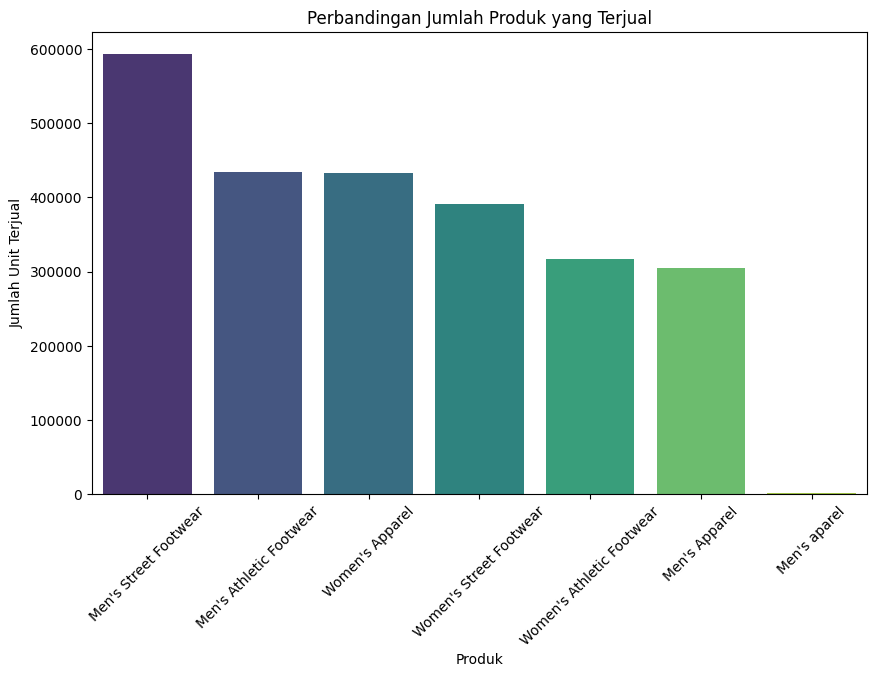

In [19]:
penjualan = df.groupby('Product')['Units Sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=penjualan.index, y=penjualan.values, palette='viridis', hue=penjualan.index, legend=False)
plt.title('Perbandingan Jumlah Produk yang Terjual')
plt.xlabel('Produk')
plt.ylabel('Jumlah Unit Terjual')
plt.xticks(rotation=45)
plt.show()

Analisis ini dilakukan dengan membandingkan total penjualan dari setiap produk yang dijual. Tujuannya adalah untuk mengetahui produk mana yang memiliki penjualan paling tinggi dan produk mana yang penjualannya paling rendah. Dan dari informasi diatas, bahwasanya produk dengan penjualan paling tinggi ada di Men's Street Footwear, dan produk dengan penjualan paling rendah ada di Men's aparel.

## **Composition/Komposisi**

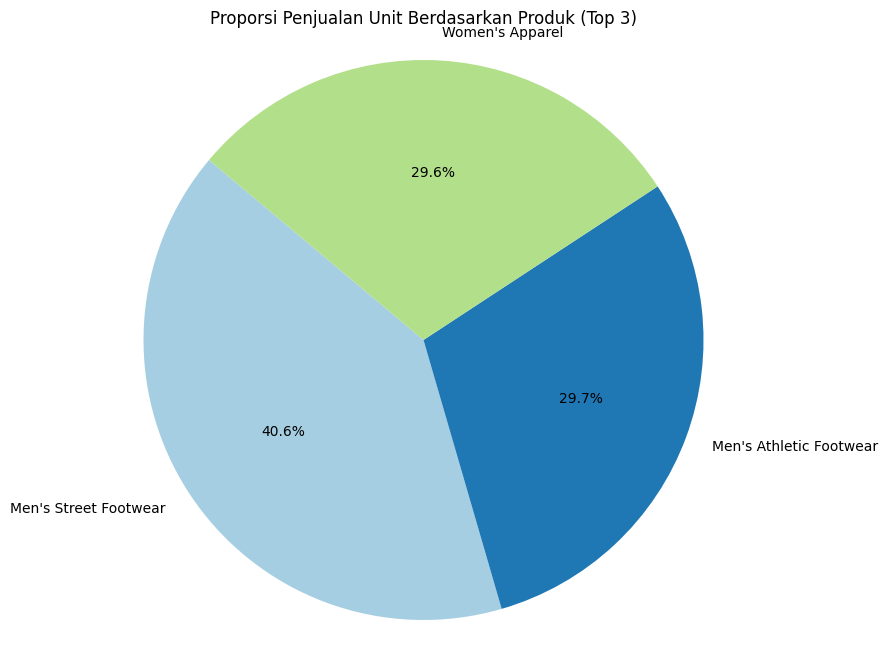

In [20]:
variabel = df.groupby('Product')['Units Sold'].sum().sort_values(ascending=False)
variabel2 = variabel.head(3)

plt.figure(figsize=(10, 8))
variabel2.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi Penjualan Unit Berdasarkan Produk (Top 3)')
plt.ylabel('')
plt.axis('equal')
plt.show()

Dari pie chart yang dihasilkan atas proporsi penjualan produk tertinggi (Top 3), dapat kita lihat bahwa penjualan produk 3 teratas terdapat pada Men's Street Footwear sebesar 40.6%, kedua teratas ada Men's Athletic Footwear sebesar 29.7%, dan ketiga teratas adaWomens Apparel sebesar 29.6%

## **Distribution/Distribusi**

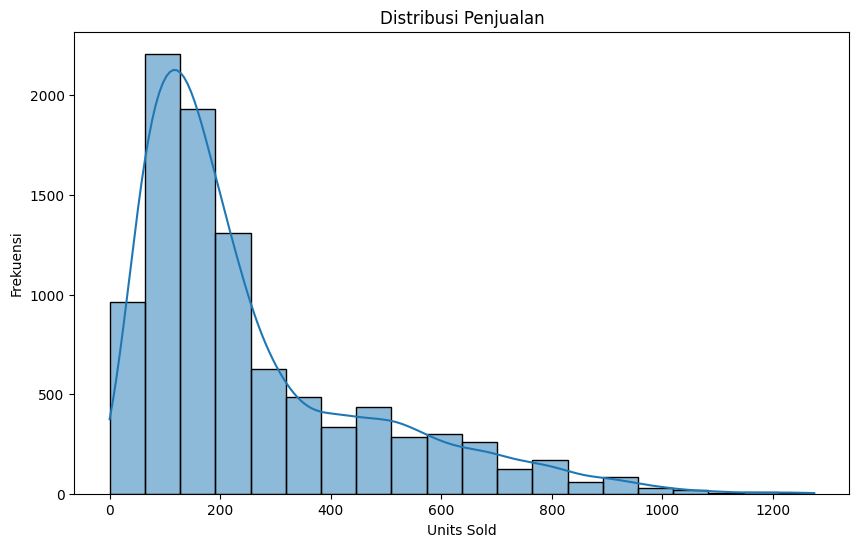

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Units Sold'], bins=20, kde=True)
plt.title('Distribusi Penjualan')
plt.xlabel('Units Sold')
plt.ylabel('Frekuensi')
plt.show()

Dari grafik yang telah ditampilkan, dapat diambil insight bahwa kebanyakan produk terjual dalam jumlah sedikit sampai sedang. Sedangkan produk yang terjual banyak itu hanya sedikit. Sebagian besar transaksi itu biasa-biasa saja, dan cuma beberapa yang benar-benar tinggi.

## **Relationship/Hubungan**

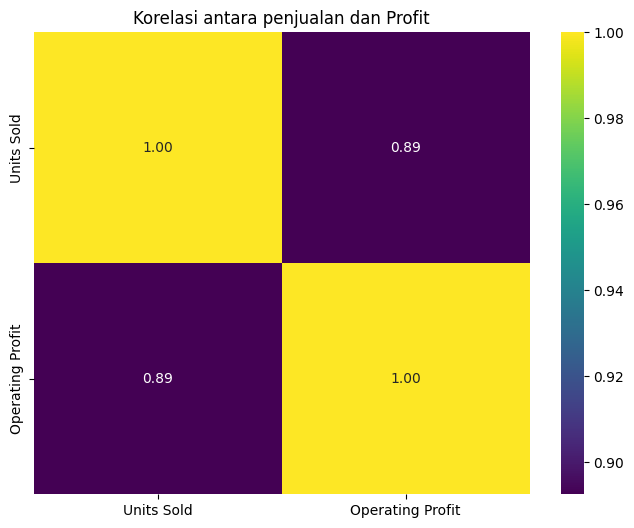

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Units Sold', 'Operating Profit']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara penjualan dan Profit')
plt.show()

Dari heatmap diatas, dapat diambil insight bahwa pada kolom Operating Profit dengan Units Sold,  kemungkinan memiliki hubungan bisa dikatakan besar. Hampir memiliki hubungan.

# **Data Preparation**

##**Penanganan Tipe Data**

Berdasarkan hasil pengecekan tipe data yang telah dilakukan sebelumnya, seluruh tipe data pada database ini sudah sesuai dengan karakteristik dan penggunaannya masing-masing. Oleh karena itu, tidak diperlukan penanganan atau perubahan tipe data lebih lanjut pada database ini.

## **Inconsistent Values**

Inconsistent Values adalah sebuah kondisi
dimana nilai-nilai dalam suatu kolom tidak
sesuai format atau memiliki tipe data yang
berbeda. Pada tahap ini kita akan menyesuaikan format penulisan agar menjaga konsistensi penulisan pada database ini.

Pada dataset ini tidak ditemukan nilai yang tidak konsisten (inconsistent values). Oleh karena itu, pada tahap Data Preparation tidak diperlukan penanganan khusus terkait inconsistent values.

## **Missing Values**

Missing Values adalah sebuah kondisi
dimana data hilang atau tidak terbaca.Pada tahap ini, data yang kosong tidak boleh dibiarkan, harus ditangani supaya analisisnya tidak error atau bias.

Pada database ini terdapat missing values pada kolom Price per Unit sebesar 0,020745%. Missing values tersebut dapat ditangani dengan melakukan imputasi pada kolom terkait agar data tetap konsisten dan dapat digunakan secara optimal dalam proses analisis selanjutnya.

In [23]:
df['Price per Unit'] = df['Price per Unit'].fillna(df['Price per Unit'].dropna().median())

Menggunakan median dikarenakan dari histogram yang sudah ditampilkan sebelumnya, histogram condong ke arah kiri. Setelah melalui tahap imputasi ini, kita bisa melakukan pengcekan kembali terhadap missing values pada database ini.

In [24]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Retailer,0.0
Retailer ID,0.0
Invoice Date,0.0
Region,0.0
State,0.0
City,0.0
Product,0.0
Price per Unit,0.0
Units Sold,0.0
Total Sales,0.0


Berdasarkan tabel missing values yang telah ditampilkan, dapat dilihat bahwa saat ini sudah tidak terdapat missing values pada database. Dengan demikian, tahap penanganan missing values dinyatakan selesai dan data siap untuk proses analisis selanjutnya.

## **Duplicated Values**

Duplicated Values adalah sebuah kondisi
dimana ada data yang muncul beberapa
kali dalam satu data set. Pada tahap ini, kita memastikan tidak ada data yang tercatat lebih dari satu kali. Data yang teridentifikasi sebagai duplikat bisa dihapus agar tidak mempengaruhi hasil analisis.

Karena pada dataset ini tidak ditemukan data yang terduplikasi, maka tidak diperlukan penanganan duplicated values pada tahap Data Preparation. Dengan demikian, tahap ini dapat dinyatakan selesai.

## **Outliers**

Outliers adalah nilai yang jauh berbeda dari
nilai lainnya dalam dataset. Nilai Outlier bisa
jauh lebih rendah atau lebih tinggi. Outlier bisa
terjadi karena berbagai alasan seperti faktor
kesalahan maupun kejadian lain yang tidak
terduga. Pada tahap ini, kita akan mendeteksi terlebih dahulu, lalu diputuskan apakah dihapus, dibiarkan, atau ditransformasi agar tidak mempengaruhi hasil analisis.

In [25]:
columns_to_impute = ["Price per Unit", "Units Sold", "Total Sales", "Operating Profit"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

/tmp/ipykernel_738/2129494513.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 2245.  1679.  7000. ... 11250.  9750.  9750.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)


In [26]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Retailer ID,45.4206
Price per Unit,0.0000
Units Sold,0.0000
Total Sales,0.0000
Operating Profit,0.0000


Setelah dilakukan transformasi pada kolom-kolom yang memiliki outlier, dapat dilihat bahwa kolom Retailer ID tidak dilakukan transformasi. Hal ini karena isi pada kolom tersebut berupa ID atau kode unik, sehingga nilai yang terdeteksi sebagai outlier masih tergolong wajar dan tidak merepresentasikan penyimpangan data numerik yang perlu ditangani.
Selain itu, berdasarkan hasil pengecekan ulang, pada kolom-kolom lainnya sudah tidak ditemukan outlier setelah proses transformasi dilakukan.

# **Construct data**

Pada tahap Construct Data ini, saya tidak melakukan penambahan kolom atau pembuatan variabel baru. Hal ini dikarenakan kolom-kolom data yang sudah tersedia dalam dataset ini telah cukup representatif dan mampu memberikan informasi yang dibutuhkan untuk proses analisis.

# **Data Reduction**

Pada tahap Data Reduction, saya tidak melakukan pengurangan atau penghapusan kolom data. Hal ini karena semua kolom yang ada masih dibutuhkan dan relevan untuk analisis. Informasi yang tersedia sudah sesuai dan tidak ada kolom yang perlu dihapus pada tahap ini.

#**Bar Chart**

Pada bar chart yang akan saya buat, kita akan melihat wilayah mana yang memiliki penjualan dan profit yang paling tinggi.

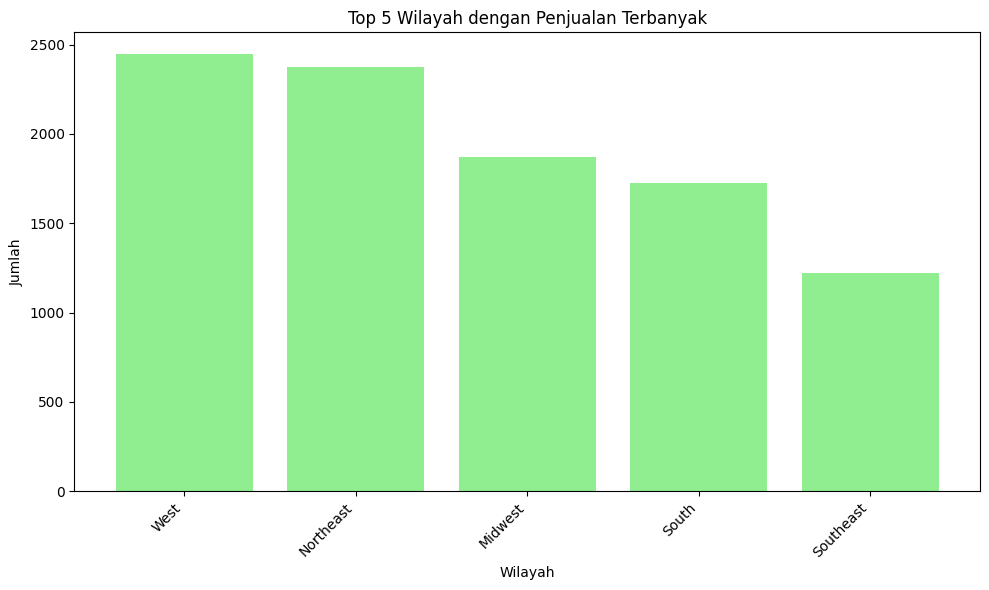

In [27]:
BARCHART = df['Region'].value_counts().head(5).sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan

plt.figure(figsize=(10, 6)) # Ukuran
plt.bar(BARCHART.index, BARCHART.values, color='lightgreen') # color warna
plt.xlabel('Wilayah') # keterangan X label
plt.ylabel('Jumlah') # keterangan y label
plt.title('Top 5 Wilayah dengan Penjualan Terbanyak') # Judul
plt.xticks(rotation=45, ha='right') # rotasi teks
plt.tight_layout()
plt.show()

##**insight**

Dari bar chart yang ditampilkan diatas, dapat kita lihat bahwasanya pada penjualan antar wilayah, pada wilayah West memiliki penjualan terbanyak dari ke lima wilayah yang ditampilkan pada bar chart tersebut dengan total penjualan sekitar hampir 2500. Dan kemudian untuk penjualan ke-2 terbanyak dari wilayah Northeast dengan total penjualan yang hanya berbeda sedikit dengan wilayah West. Dengan wilayah tertinggi ke-3 yaitu Midwest dengan total penjualan hampir menyentuh angka 2000, selanjutnya daro wilayah South yang total penjualannya tidak berbeda jauh juga dengan Midwest. Dan wilayah dengan total penjualan tertinggi ke-5 ada pada wilayah Southeast dengan total penjualan hampir mencapai 1500  penjualan.

##**Action**

Berdasarkan hasil tersebut, perusahaan dapat mempertahankan strategi penjualan yang sudah berjalan dengan baik di wilayah West dan Northeast, karena kedua wilayah tersebut memberikan kontribusi penjualan terbesar. Di sisi lain, wilayah seperti Southeast dapat menjadi fokus untuk peningkatan strategi pemasaran atau promosi, agar penjualannya bisa lebih meningkat dan lebih seimbang dengan wilayah lainnya.

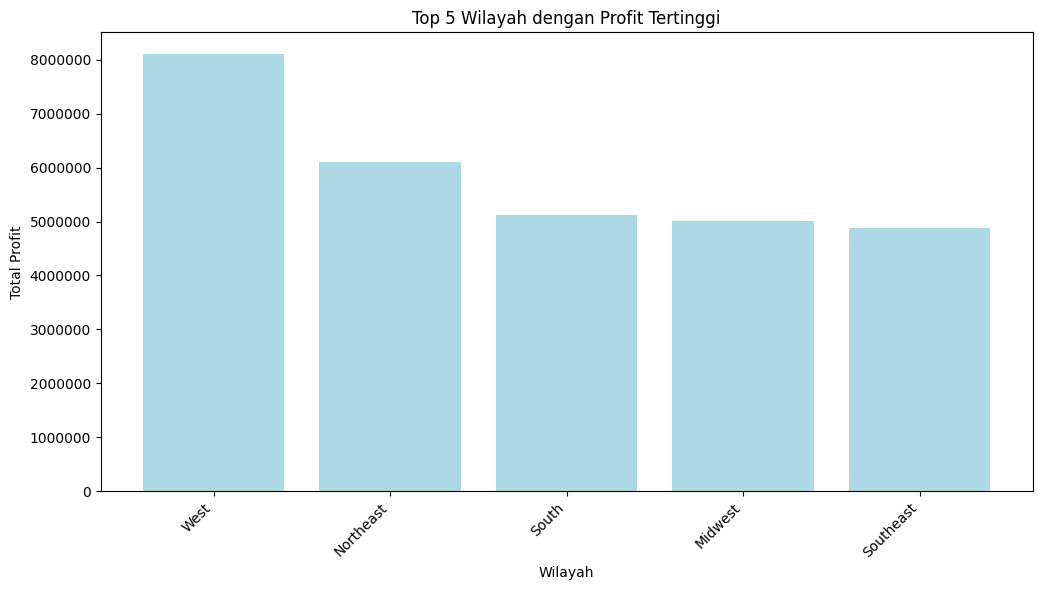

In [28]:
BARCHART = df.groupby('Region')['Operating Profit'].sum().sort_values(ascending=False).head(5) # head() jumlah yang mau ditampilkan & Urutan

plt.figure(figsize=(10, 6))  # Ukuran
plt.bar(BARCHART.index, BARCHART.values, color='lightblue') # color warna
plt.xlabel('Wilayah') # keterangan X label
plt.ylabel('Total Profit') # keterangan y label
plt.title('Top 5 Wilayah dengan Profit Tertinggi') # Judul
plt.xticks(rotation=45, ha='right') # rotasi teks
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

##**insight**

Kemudian dari bar chart diatas inii jugha, kita dapat melihat Top 5 wilayah dengan profit penjualan tertinggi. yang pertama ada dari wilayah West dengan profit mencapai 8000000, wilayah tertinggi ke-2 ada pada Northeast dengan profit mencapai 6000000, yang ke-3 dari wilayah South dengan profit 5000000. selanjutnya dari wilayah Midwest dengan profit yang tidak begitu jauh dibandingkan dengan wilayah South, dan wilayah dengan profit penjualan tertinggi yang ke-5 ada pada wilayah Southeast dengan profit yang hampir sama juga dengan wilayah sebelumnya, yaitu Midwest.

##**Action**

Berdasarkan hasil ini, perusahaan dapat terus mempertahankan strategi penjualan di wilayah West dan Northeast karena kedua wilayah tersebut memberikan kontribusi profit paling besar. Selain itu, wilayah seperti Midwest dan Southeast dapat menjadi fokus untuk peningkatan strategi penjualan atau efisiensi biaya, sehingga profit yang dihasilkan bisa lebih meningkat dan mendekati wilayah dengan performa tertinggi.

#**Pie Chart**

Pada pie chart disini, saya akan menampilkan proporsi penjualan berdasarkan metode penjualan. Yang dimana akan memberikamn insight bahwa metode penjualan mana yang lebih efektif digunakan.  

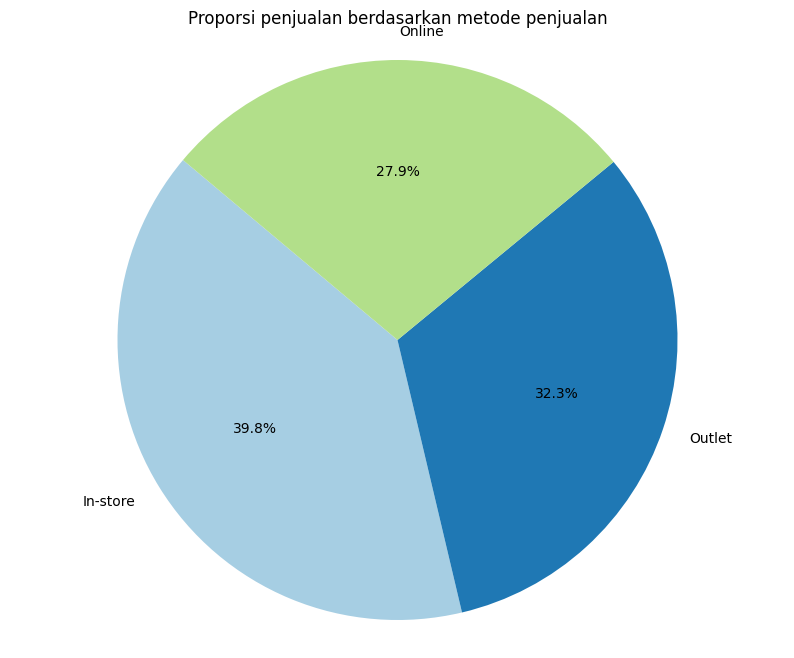

In [29]:
PieChart = df.groupby('Sales Method')['Total Sales'].sum().sort_values(ascending=False)
Top3Sales = PieChart.head()

plt.figure(figsize=(10, 8)) # Ukuran
Top3Sales.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi penjualan berdasarkan metode penjualan') # Judul
plt.ylabel('') # Keterangan Y
plt.axis('equal')
plt.show()

##**insight**

Dapat kita lihat dari pie chart yang telah ditampilkan, menunjukkan bahwasanya metode penjualan yang paling tinggi persentasi nya ada pada penjualan in-store yang dimana persentasi menunjukkan 39.8%, metode penjualan kedua diikuti oleh metode penjualan Outlet yang dimana persentasi nya sebesar 32.35, dan untuk metode penjualan yang memi9liki persentasi paling kecil yaitu online dengan persentasi sebesar 27.9%. Dapat diambil kesimpulan, bahwasanya orang-orang lebih memilih untuk membeli produk in-store atau membeli langsung di  toko utama atau toko resmi produk.

##**Action**

Berdasarkan hasil tersebut, perusahaan dapat terus mempertahankan kualitas layanan dan ketersediaan produk di toko fisik karena metode ini memberikan kontribusi penjualan terbesar. Di sisi lain, penjualan online juga bisa lebih ditingkatkan, misalnya dengan promosi digital, diskon khusus online, atau peningkatan pengalaman belanja di platform online agar lebih banyak pelanggan tertarik untuk berbelanja secara digital.

#**Line Chart**

Pada line chart, saya menggunakan kolom Invoice Date untuk melihat tren penjualan bulanan ole penjualan produk.

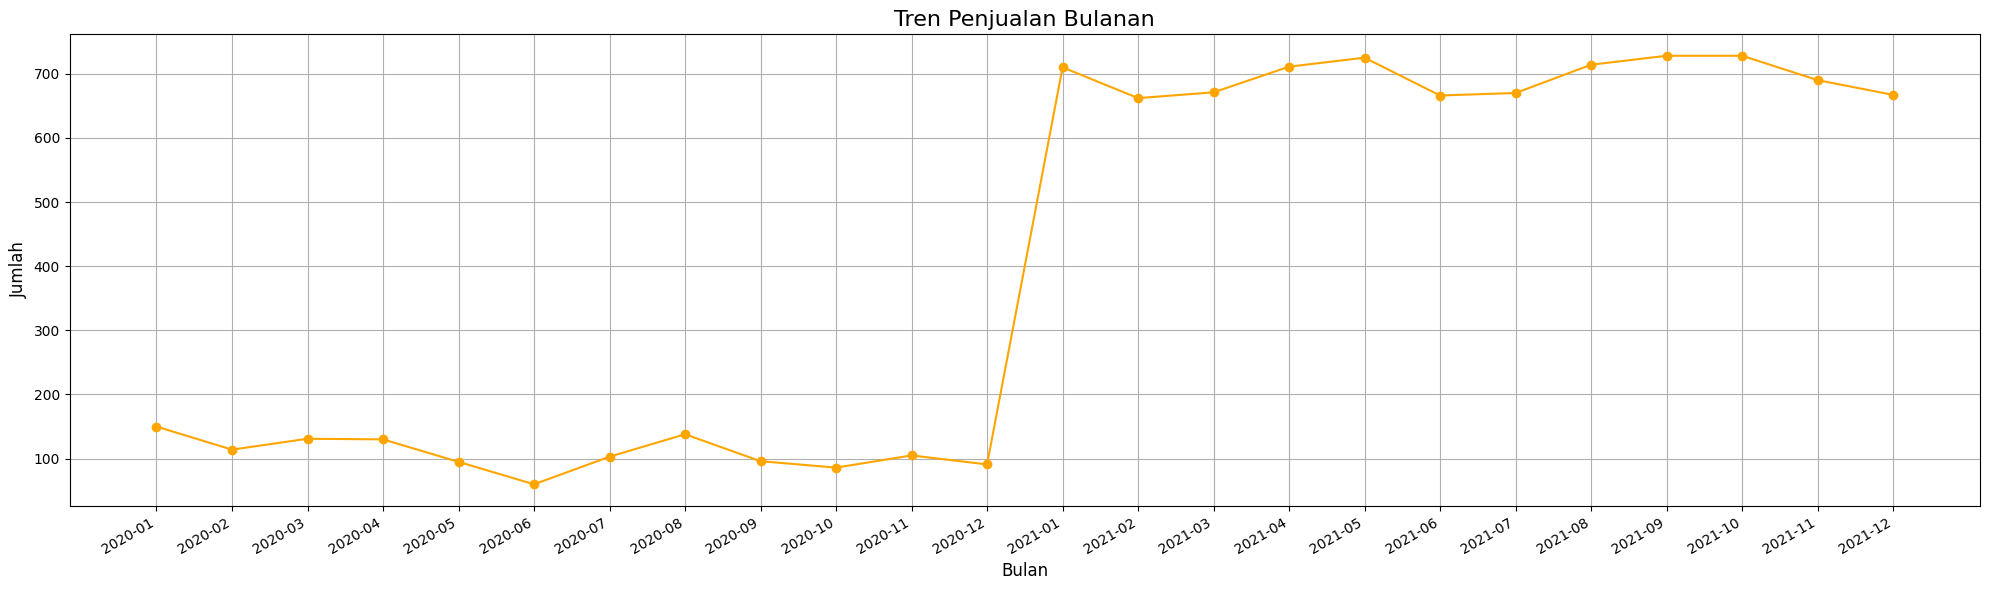

In [30]:
# Pastikan kolom bertipe datetime

# Group by month
LINECHART = df.groupby(df['Invoice Date'].dt.to_period('M')).size()

plt.figure(figsize=(20, 6)) # Ukuran figure diperbesar untuk kejelasan
plt.plot(LINECHART.index.astype(str), LINECHART.values, marker='o', color='orange') # Mengubah warna agar berbeda
plt.title('Tren Penjualan Bulanan', fontsize=16) # Judul
plt.xlabel('Bulan', fontsize=12) # X Keterangan
plt.ylabel('Jumlah', fontsize=12) # Y Keterangan
plt.grid(True)
plt.gcf().autofmt_xdate() # Otomatis mengatur format dan rotasi di sumbu X
plt.tight_layout()
plt.show()

##**insight**

Dari grafik ini, menunjukkan bahwa bisnis berhasil "naik kelas" secara drastis di awal tahun 2021. Jika sepanjang 2020 penjualan masih rendah dan sering naik-turun di bawah 200 unit, memasuki Januari 2021 terjadi lonjakan masif hingga menyentuh angka 700 unit yang menandakan keberhasilan strategi besar pada masa tersebut. Menariknya, kenaikan ini bukan sekadar tren sesaat karena penjualan mampu bertahan stabil di level tinggi sepanjang tahun 2021, yang membuktikan bahwa bisnis pada tahun 2021 ini sudah memiliki basis konsumen yang jauh lebih kuat dan matang dibandingkan tahun sebelumnya.

##**Action**

Berdasarkan hasil tersebut, perusahaan dapat mempertahankan strategi penjualan atau pemasaran yang diterapkan pada tahun 2021, karena strategi tersebut terbukti mampu meningkatkan penjualan secara signifikan. Selain itu, perusahaan juga dapat meningkatkan kesiapan stok produk dan distribusi barang, agar dapat memenuhi permintaan yang lebih tinggi dan menjaga kestabilan penjualan di periode berikutnya.

#**Histogram**

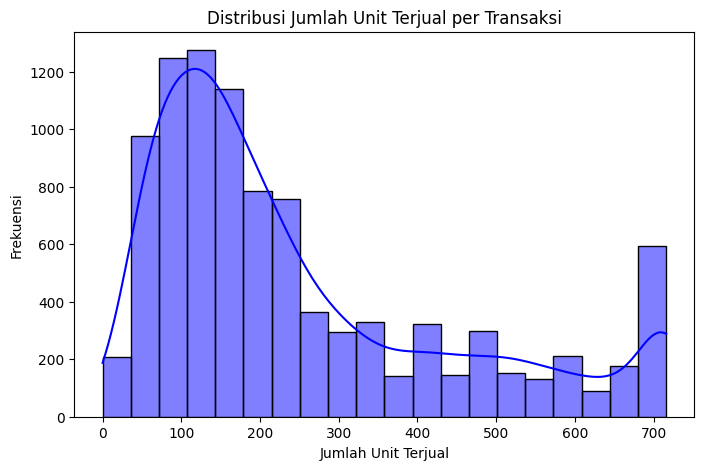

In [31]:
# Histogram (Seaborn)
plt.figure(figsize=(8, 5))
sns.histplot(df['Units Sold'], bins=20, kde=True, color='blue')
plt.title('Distribusi Jumlah Unit Terjual per Transaksi')
plt.xlabel('Jumlah Unit Terjual')
plt.ylabel('Frekuensi')
plt.show()

##**insight**

Berdasarkan histogram “Distribusi Jumlah Unit Terjual per Transaksi”, sebagian besar transaksi berada pada kisaran 50–200 unit, yang berarti kebanyakan pembelian dilakukan dalam jumlah sedang. Sementara itu, transaksi dengan jumlah unit yang sangat besar hingga mendekati 700 unit juga ada, tetapi tidak terlalu sering terjadi dibandingkan transaksi pada kisaran tersebut.

##**Action**

Berdasarkan hasil ini, perusahaan dapat memfokuskan strategi penjualan pada transaksi dengan jumlah pembelian sedang, misalnya dengan menyediakan paket produk atau promo khusus pada kisaran jumlah tersebut karena merupakan pola pembelian yang paling umum. Selain itu, perusahaan juga dapat memberikan penawaran khusus atau diskon untuk pembelian dalam jumlah besar, sehingga dapat mendorong lebih banyak pelanggan melakukan pembelian dengan jumlah unit yang lebih tinggi.

#**Boxplot**

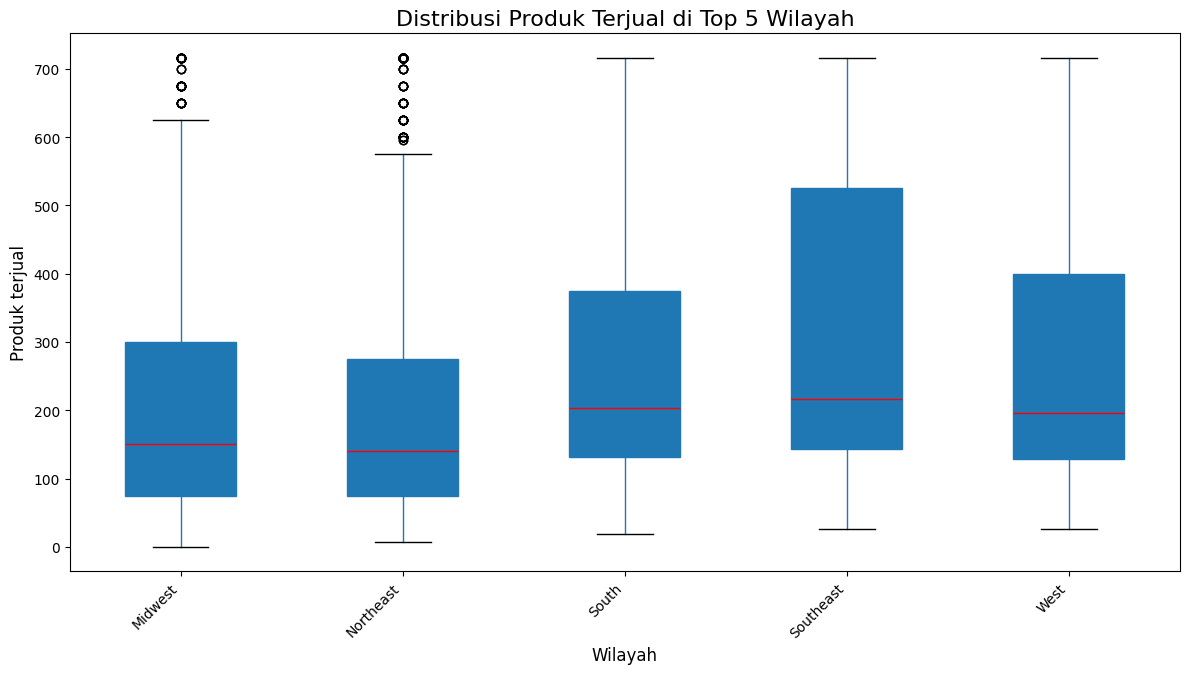

In [35]:
# Boxplot (Matplotlib): Units Sold berdasarkan Top 5 Wilayah

# Identifikasi 5 Wilayah teratas berdasarkan jumlah entri
top5Wilayah = df['Region'].value_counts().head(5).index

# Filter DataFrame untuk hanya menyertakan 5 Wilayah teratas
df_top5_Wilayah = df[df['Region'].isin(top5Wilayah)]

plt.figure(figsize=(12, 7)) # Ukuran figure
df_top5_Wilayah.boxplot(column='Units Sold', by='Region', ax=plt.gca(), grid=False, patch_artist=True, medianprops=dict(color='red'))
plt.title('Distribusi Produk Terjual di Top 5 Wilayah', fontsize=16) # Judul
plt.xlabel('Wilayah', fontsize=12) # X Keterangan
plt.ylabel('Produk terjual', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right')
plt.suptitle('') # Menghilangkan judul default dari boxplot.by
plt.tight_layout()
plt.show()

##**insight**

Dari boxplot “Distribusi Units Sold di Top 5 Wilayah”, terlihat adanya beberapa outlier pada wilayah Midwest dan Southeast. Outlier ini menunjukkan adanya transaksi dengan jumlah unit terjual yang jauh lebih tinggi dibandingkan transaksi lainnya di wilayah tersebut. Hal ini kemungkinan terjadi karena adanya pembelian dalam jumlah besar pada waktu tertentu. Sementara itu, pada wilayah lain seperti South, Northeast, dan West tidak terlihat outlier yang menonjol, sehingga jumlah unit yang terjual di wilayah-wilayah tersebut cenderung lebih berada dalam rentang yang wajar.

##**Action**

Berdasarkan hasil ini, perusahaan dapat menganalisis lebih lanjut penyebab terjadinya pembelian dalam jumlah besar di wilayah Midwest dan Southeast, misalnya apakah berasal dari pelanggan besar, promo tertentu, atau kebutuhan pasar yang tinggi pada waktu tertentu. Jika peluang tersebut dapat dimanfaatkan, perusahaan dapat meningkatkan strategi penjualan seperti menawarkan program pembelian dalam jumlah besar atau kerja sama dengan pelanggan skala besar di wilayah tersebut untuk meningkatkan penjualan.

#**Scatter Plot**

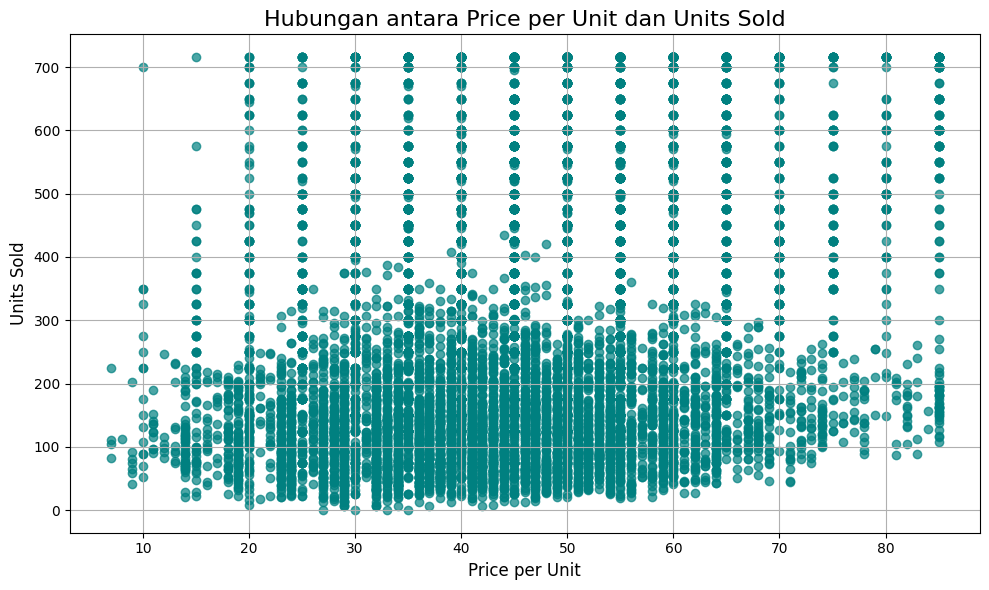

In [37]:
# Scatter Plot (Matplotlib): Price per Unit vs Units Sold

plt.figure(figsize=(10, 6)) # Ukuran
plt.scatter(df['Price per Unit'], df['Units Sold'], alpha=0.7, color='teal') # Color (Warna)
plt.title('Hubungan antara Price per Unit dan Units Sold', fontsize=16) # Judul
plt.xlabel('Price per Unit', fontsize=12) # X Keterangan
plt.ylabel('Units Sold', fontsize=12) # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

##**insight**

Untuk melihat apakah harga mempengaruhi jumlah produk yang terjual, digunakan scatter plot yang membandingkan Price per Unit dengan Units Sold. Dari grafik tersebut terlihat bahwa titik-titik data tersebar cukup acak, sehingga tidak terlihat hubungan yang kuat antara harga produk dan jumlah unit yang terjual. Artinya, perubahan harga tidak selalu diikuti dengan perubahan jumlah unit yang terjual secara jelas. Selain itu, sebagian besar transaksi berada pada kisaran sekitar 50–250 unit terjual, meskipun ada beberapa transaksi dengan jumlah unit yang jauh lebih tinggi hingga di atas 700 unit. Hal ini menunjukkan bahwa harga bukan satu-satunya faktor yang mempengaruhi jumlah produk yang terjual.

##**Action**

Berdasarkan hasil ini, perusahaan dapat lebih fokus pada faktor lain selain harga, seperti strategi promosi, kualitas produk, atau metode penjualan untuk meningkatkan jumlah penjualan. Selain itu, perusahaan juga dapat melakukan analisis lebih lanjut terhadap faktor lain yang mungkin mempengaruhi penjualan, seperti wilayah penjualan, metode penjualan, atau waktu transaksi, sehingga strategi bisnis yang dibuat dapat lebih efektif dalam meningkatkan jumlah unit yang terjual.

#**Bubble Chart**

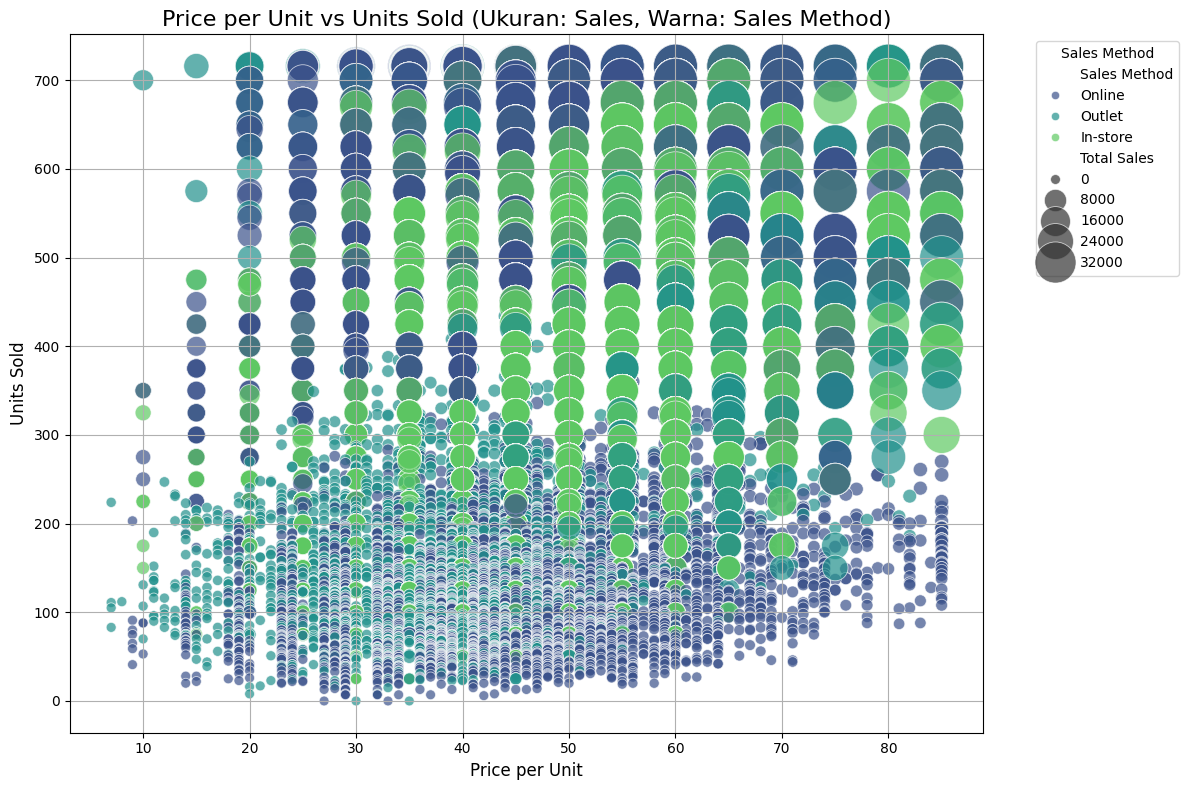

In [39]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Price per Unit', y='Units Sold', size='Total Sales', hue='Sales Method', data=df, sizes=(50, 1000), alpha=0.7, palette='viridis')
plt.title('Price per Unit vs Units Sold (Ukuran: Sales, Warna: Sales Method)', fontsize=16)
plt.xlabel('Price per Unit', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.grid(True)
plt.legend(title='Sales Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##**insight**

Dari bubble chart tersebut terlihat bahwa titik-titik data masih tersebar cukup luas, sehingga tidak menunjukkan hubungan yang terlalu kuat antara Price per Unit dan Units Sold. Artinya, kenaikan harga tidak selalu membuat jumlah unit yang terjual menjadi lebih rendah atau lebih tinggi secara konsisten. Selain itu, terlihat bahwa bubble yang lebih besar (Total Sales lebih tinggi) banyak muncul pada transaksi dengan Units Sold yang tinggi, yang menunjukkan bahwa nilai penjualan besar lebih sering terjadi ketika jumlah unit yang dibeli juga banyak. Dari sisi warna, terlihat bahwa metode penjualan In-store cukup sering muncul pada transaksi dengan jumlah unit yang tinggi dibandingkan metode lainnya, sementara Online dan Outlet lebih banyak tersebar pada transaksi dengan jumlah unit yang lebih kecil hingga menengah.

##**action**

Berdasarkan hasil ini, perusahaan dapat lebih mendorong penjualan dengan meningkatkan jumlah unit yang dibeli dalam satu transaksi, misalnya melalui promo bundling atau diskon untuk pembelian dalam jumlah tertentu. Selain itu, karena metode In-store terlihat sering menghasilkan transaksi dengan unit yang lebih besar, perusahaan dapat memperkuat strategi penjualan di toko fisik, seperti promosi langsung di toko atau program loyalitas pelanggan. Di sisi lain, metode Online dan Outlet juga dapat ditingkatkan dengan strategi promosi khusus, agar dapat mendorong pelanggan melakukan pembelian dengan jumlah unit yang lebih besar.

#**Heatmap**

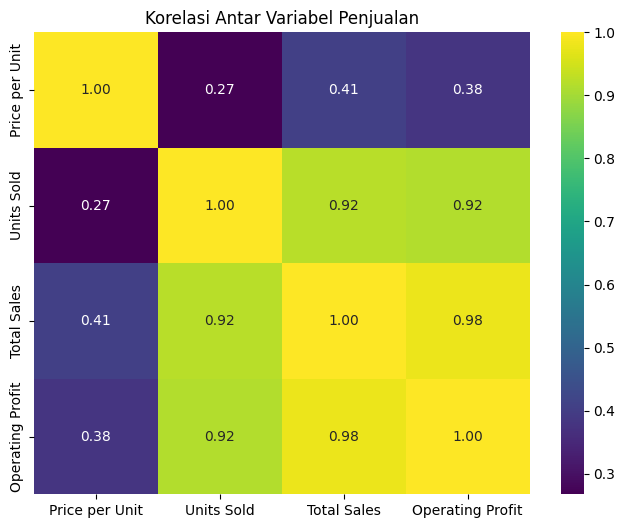

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi Antar Variabel Penjualan')
plt.show()

##**insight**

Berdasarkan heatmap korelasi tersebut, terlihat bahwa Units Sold memiliki hubungan yang sangat kuat dengan Total Sales dan Operating Profit, dengan nilai korelasi sekitar 0.92. Hal ini menunjukkan bahwa semakin banyak unit yang terjual, maka total penjualan dan keuntungan yang dihasilkan juga cenderung meningkat secara signifikan. Selain itu, Total Sales dan Operating Profit memiliki korelasi yang sangat tinggi yaitu sekitar 0.98, yang berarti peningkatan total penjualan hampir selalu diikuti dengan peningkatan keuntungan. Sementara itu, Price per Unit memiliki korelasi yang relatif lemah dengan variabel lainnya, seperti Units Sold (0.27), Total Sales (0.41), dan Operating Profit (0.38). Hal ini menunjukkan bahwa perubahan harga tidak terlalu berpengaruh secara langsung.

##**action**

Berdasarkan hasil tersebut, perusahaan dapat lebih fokus pada strategi yang mampu meningkatkan jumlah unit yang terjual, seperti promosi, paket bundling, atau diskon pembelian dalam jumlah tertentu, karena peningkatan unit terjual terbukti sangat berpengaruh terhadap penjualan dan keuntungan. Selain itu, karena harga tidak memiliki hubungan yang terlalu kuat dengan penjualan, perusahaan dapat lebih fleksibel dalam menentukan strategi harga, misalnya dengan memberikan promo atau penyesuaian harga tanpa terlalu khawatir akan menurunkan jumlah penjualan secara drastis.